In [ ]:
from hm10 import SharedData, Hm10Device, DoubleConsumer
import argparse
import time
from IPython.display import clear_output
%pip install -e "C:\Users\admin\Downloads\Arm_v4\Arm_v4\Python"
from posetracker import PoseTracker
tracker = PoseTracker(n_nutation_zones=180, n_precession_zones=360)

Obtaining file:///C:/Users/admin/Downloads/Arm_v4/Arm_v4/Python
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for posetracker (pyproject.toml): started
  Building editable for posetracker (pyproject.toml): finished with status 'done'
  Created wheel for posetracker: filename=posetracker-0.1.0-0.editable-py3-none-any.whl size=2852 sha256=dc9d605d0abf0f607f5e127425afa21f81076ff7a21d4852abc18476935f77a0
  Stored in directory: C:\Users\admin\AppData\Local\Temp\pip-ephem-wheel-cache-n_qza1cd\wheels\b3\72\c2\5c06c45711d720aa22a138

In [2]:
import serial
import serial.tools.list_ports
import time
from time import sleep
import os
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
# import seaborn as sns
from datetime import timezone
from datetime import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import interpolate
import json
import pylsl

from IPython.display import display
from IPython.display import clear_output
import matplotlib
font = {        'size'   : 42}
matplotlib.rc('font', **font)
              
%config Completer.use_jedi = False

from pylsl import  StreamInfo, StreamInlet, StreamOutlet


In [3]:
from hm10 import SharedData, Hm10Device, DoubleConsumer
import argparse
import time
import numpy as np
import pandas as pd
from IPython.display import clear_output, display



# Connecting to the BLE module (Connexion to  Bluetooth) 

In [4]:
p = argparse.ArgumentParser(description="HM-10 producer/consumer demo")
p.add_argument("--filter", default="HM-10")
p.add_argument("--duration", type=float, default=0, help="сек; 0 = пока Ctrl+C")
args, unknown = p.parse_known_args()

shared = SharedData()
device = Hm10Device(shared, flt=args.filter)
device.start()

consumer = DoubleConsumer(shared)
consumer.start()

[device] found 34:15:13:DE:B7:02
[device] connected, streaming...


In [5]:
print("Подключаюсь")
tracker.connect()
print("Подключился")

Подключаюсь
Подключился


In [30]:
input("Встаньте прямо, руки вдоль тела, потом Enter (и замрите на 3 сек)...")
tracker.calibrate_g()

input("Вытяните руку вперёд, потом Enter (и замрите на 1.5 сек)...")
tracker.calibrate_f()

input("Наклонитесь вперёд, потом Enter (и задержитесь на 2 сек)...")
tracker.calibrate_l()

tracker.finalize_calibration()
print("Калибровка готова.\n")

Встаньте прямо, руки вдоль тела, потом Enter (и замрите на 3 сек)... 
Вытяните руку вперёд, потом Enter (и замрите на 1.5 сек)... 
Наклонитесь вперёд, потом Enter (и задержитесь на 2 сек)... 


Калибровка готова.



# defining functions to set up max and min valus de l amplitude

In [7]:
from scipy import interpolate

def minmax(x, min_x, max_x):
    return np.clip((x.astype(np.int32) - min_x) / (max_x - min_x), 0, 1)

def interpolation_mode(min_sens, max_sens, inv, min_param_value, max_param_value, params_range):
    
    print(params_range)
    xi_n = yi_n = np.linspace(0, 1, params_range)
    xi = np.linspace(min_sens, max_sens, params_range)
    yi = np.linspace(min_param_value, max_param_value, params_range)
    if inv:
        xi_n = xi_n[::-1]
        xi = xi[::-1]
    return interpolate.interp1d(x=np.flip(xi_n), y=yi, kind='linear'), xi_n, xi, yi_n, yi

def interpolate_manual(value,max_value,min_value):
    amp_max_local = int((max_value - min_value) / 0.1) + 1
    yi = np.linspace(min_value, max_value, amp_max_local)
    log_values_sensor = np.geomspace(1, 0.01, amp_max_local)
    if value > 0.01:
        ind = np.where(log_values_sensor < value)[0][0] - 1
        out = np.round(yi[ind], 1)
    else:
        out = yi[-1]
    return out

def remove_outliers_numpy(data):
    arr = np.array(data)
    #q1, q3 = np.percentile(arr, [25, 75])
    #iqr = q3 - q1
    
    lower_bound = 1000
    upper_bound = 3000
    print('lower_bound',lower_bound)
    print('upper_bound',upper_bound)
    # Возвращаем обычный python-список
    return arr[(arr >= lower_bound) & (arr <= upper_bound)].tolist()

# Defining from which sensors we will use to drive the stimulation

In [8]:
cols_list = ['Aperture', 'Index', 'Thumb']
included_data = {'Aperture': False, 'Index': True, 'Thumb': False}   # which channel drives the stim
included_data_list = np.array([included_data[k] for k in cols_list])

In [42]:
freq = 55
pw = 100
amplitude_max = 1.3   # Max comfortable amplitude
amplitude_min = 0.3   # Amplitude where sensation starts
#amp_max = int(((amplitude_max + 0.1) - (amplitude_min - 0.1)) // 0.1) + 1
#print(amp_max)


frequency_max=100
frequency_min=30
#freq_max = int(((frequency_max + 1) - (frequency_min - 1)) // 1) + 1
#print(freq_max)

In [31]:
print('Data gathering started — touch/move each sensor (Aperture, Index, Thumb).')
print('Press the Stop button (■) when done.')

collected = []

try:
    while True:
        frame = consumer.shared.try_pop()
        if frame is None:
            time.sleep(0.005)
            continue
        if (0<=frame.aperture<4096) and (0<=frame.press1<4096) and (0<=frame.press2<4096):
            collected.append([frame.aperture, frame.press1, frame.press2])
            print(f"[{consumer.name}] aperture={frame.aperture} "
                  f"Index={frame.press1} Thumb={frame.press2} ts={frame.ts}")
        clear_output(wait=True)
except KeyboardInterrupt:
    print(f'Stopped. {len(collected)} samples collected.')

values = np.array(collected).astype(float)
display(pd.DataFrame(collected, columns=cols_list, dtype=float))
display('Minimum and Maximum values:')
display(pd.DataFrame(values, columns=cols_list).min())
display(pd.DataFrame(values, columns=cols_list).max())

Stopped. 382 samples collected.


,Aperture,Index,Thumb
0,2170.0,0.0,0.0
1,2169.0,0.0,0.0
2,2170.0,0.0,0.0
3,2170.0,0.0,0.0
4,2167.0,0.0,0.0
...,...,...,...
377,2170.0,0.0,0.0
378,2170.0,0.0,0.0
379,2166.0,0.0,0.0
380,2169.0,0.0,0.0


'Minimum and Maximum values:'

Aperture    2163.0
Index          0.0
Thumb          0.0
dtype: float64

Aperture    2739.0
Index       1843.0
Thumb       1811.0
dtype: float64

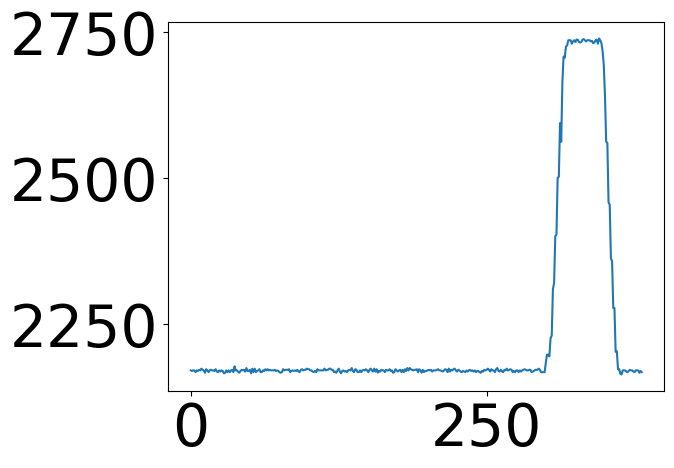

lower_bound 1000
upper_bound 3000


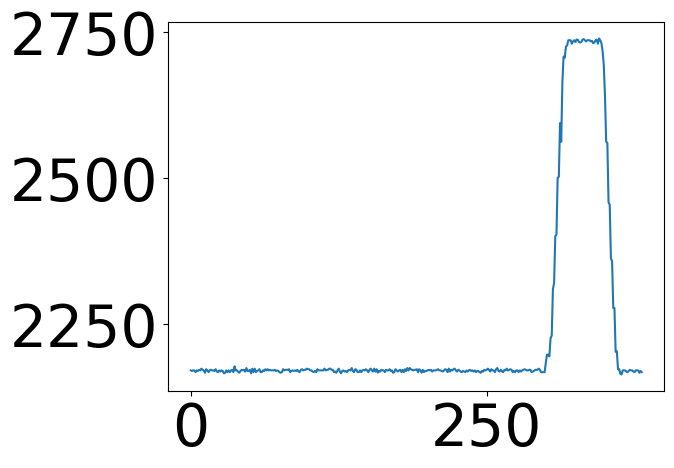

In [32]:
coll=pd.DataFrame(collected, columns=cols_list, dtype=float)
plt.plot(coll['Aperture'].values)
plt.show()
val_=remove_outliers_numpy(coll['Aperture'].values)
plt.plot(val_)
plt.show()


In [12]:
int(((frequency_min + 1) - (frequency_max - 1))) + 1

-67

In [13]:
min

<function min>

In [43]:
print('Threshold Search... Started')
thresholds_dict = {}
Thresholds_norm, Thresholds = [], []
Amps_norm, Amps = [], []
Funcs = []
maxs_, bases_ = [], []

for i, vals in enumerate(values.T):
    if cols_list[i]=='Aperture':
        vals=remove_outliers_numpy(vals)
    maxs_.append(max(vals))
    bases_.append(min(vals))
    if maxs_[-1] > 0:
        print(cols_list[i])
        if cols_list[i]=='Aperture':
            params_range = int(((frequency_max + 1) - ( frequency_min - 1)) // 1) + 1
            func, norm_sens, dat_sens, norm_amp, dat_amp = interpolation_mode(
                min_sens=maxs_[-1], max_sens=bases_[-1], inv=True,  min_param_value=frequency_min, max_param_value=frequency_max, params_range=params_range)
        else:
            params_range = int(((amplitude_max + 0.1) - (amplitude_min - 0.1)) // 0.1) + 1
            func, norm_sens, dat_sens, norm_amp, dat_amp = interpolation_mode(
                min_sens=maxs_[-1], max_sens=bases_[-1], inv=True,  min_param_value=amplitude_min, max_param_value=amplitude_max,  params_range=params_range)
            
        Funcs.append(func)
        Thresholds_norm.append(norm_sens)
        Thresholds.append(dat_sens)
        Amps_norm.append(norm_amp)
        Amps.append(dat_amp)
    else:
        Funcs.append(np.nan)
        Thresholds_norm.append(np.array([np.nan] * len(vals)))
        Thresholds.append(np.array([np.nan] * len(vals)))
        Amps_norm.append(np.array([np.nan] * len(vals)))
        Amps.append(np.array([np.nan] * len(vals)))
    print(maxs_[i])

for i in range(len(cols_list)):

    
    if cols_list[i]=='Apterture':
        pass

    else:
        thresholds_dict[cols_list[i]] = dict(
            MaxValues=maxs_[i], BaseValues=bases_[i],
            Thr_NORM=Thresholds_norm[i], Thr_DATA=Thresholds[i],
            InterpFunc=Funcs[i],
            Amp_NORM=Amps_norm[i], Amp_DATA=Amps[i],
            Amp_Max=amplitude_max, Amp_Min=amplitude_min
        )

print('Threshold Search... Ended')
df_thresholds = pd.DataFrame(thresholds_dict)
display(df_thresholds)

Threshold Search... Started
lower_bound 1000
upper_bound 3000
Aperture
73
2739.0
Index
13
1843.0
Thumb
13
1811.0
Threshold Search... Ended


,Aperture,Index,Thumb
MaxValues,2739.0,1843.0,1811.0
BaseValues,2163.0,0.0,0.0
Thr_NORM,"[1.0, 0.986111111111111, 0.9722222222222222, 0...","[1.0, 0.9166666666666666, 0.8333333333333333, ...","[1.0, 0.9166666666666666, 0.8333333333333333, ..."
Thr_DATA,"[2163.0, 2171.0, 2179.0, 2187.0, 2195.0, 2203....","[0.0, 153.58333333333326, 307.1666666666665, 4...","[0.0, 150.91666666666674, 301.8333333333335, 4..."
InterpFunc,<scipy.interpolate._interpolate.interp1d objec...,<scipy.interpolate._interpolate.interp1d objec...,<scipy.interpolate._interpolate.interp1d objec...
Amp_NORM,"[0.0, 0.013888888888888888, 0.0277777777777777...","[0.0, 0.08333333333333333, 0.16666666666666666...","[0.0, 0.08333333333333333, 0.16666666666666666..."
Amp_DATA,"[30.0, 30.97222222222222, 31.944444444444443, ...","[0.3, 0.3833333333333333, 0.4666666666666667, ...","[0.3, 0.3833333333333333, 0.4666666666666667, ..."
Amp_Max,1.3,1.3,1.3
Amp_Min,0.3,0.3,0.3


In [44]:
included_data_list_indices = np.where(included_data_list == True)[0]
tensometer_fingers = np.array(cols_list)[included_data_list_indices]
print(tensometer_fingers)

minPres = df_thresholds[tensometer_fingers[:]].loc['BaseValues'].to_numpy().astype(int)
minAper = df_thresholds[['Aperture']].loc['BaseValues'].to_numpy().astype(int)

maxPres = df_thresholds[tensometer_fingers[:]].loc['MaxValues'].to_numpy().astype(int)
maxAper=  df_thresholds[['Aperture']].loc['MaxValues'].to_numpy().astype(int)

print( 'minPres', minPres)
print( 'minAper', minAper)

print( 'maxPres', maxPres)
print( 'maxAper', maxAper)

['Index']
minPres [0]
minAper [2163]
maxPres [1843]
maxAper [2739]


# Start stimulation

In [19]:
import IOM

In [20]:
IOM = IOM.IOMStimulator()

Not assigned yet
Электростимулятор многоканальный/Нейро-МВП вер. 2


In [21]:
freq=55  # Starting freq
pulse_width=100
IOM.default_setting()
# IOM.change_amplitude(amplitude)
IOM.change_pw(pulse_width)
IOM.change_frequency(freq)

In [22]:
IOM.get_setting()

Amp: 0.0, Freq: 55.0, PW: 99.99999747378752


In [23]:
IOM.change_amplitude(0)

In [24]:
IOM.get_setting()

Amp: 0.0, Freq: 55.0, PW: 99.99999747378752


In [25]:
IOM.begin_stim_full()

### Classical 

### Speed 

# Плавный коэффициент по прецессии (провал вокруг заданной зоны)

In [ ]:
def linear_dip_coefficient(zone, n_zones, min_zone, min_coef, ramp_zones):
    """1.0 везде, кроме "провала" вокруг zone=min_zone (там a=min_coef),
    линейно возвращается к 1.0 на расстоянии ramp_zones зон в КАЖДУЮ
    сторону от min_zone. Расстояние считается по кругу (зона n_zones
    соседствует с зоной 1) - важно для прецессии, которая описывает
    полный оборот на 360°.

    Пример: n_zones=360, min_zone=90, min_coef=0.5, ramp_zones=20 ->
      зона 70: a=1.0, зона 90: a=0.5, зона 110: a=1.0, везде вне [70,110] - a=1.0.
    """
    raw_diff = abs(zone - min_zone) % n_zones
    dist = min(raw_diff, n_zones - raw_diff)
    if dist >= ramp_zones:
        return 1.0
    frac = dist / ramp_zones
    return min_coef + (1.0 - min_coef) * frac

# Параметры провала - подбираются под задачу, как и amplitude_min/max выше.
DIP_MIN_ZONE = 90     # зона (=градус, т.к. n_precession_zones=360) с минимумом коэффициента
DIP_MIN_COEF = 0.5    # во сколько раз занижаем stim_amp_set в зоне DIP_MIN_ZONE
DIP_RAMP_ZONES = 20   # сколько зон в каждую сторону занимает линейный переход обратно к 1.0

In [ ]:
IOM.begin_stim_full()
IOM.change_amplitude(amplitude_min)
counter=0
stim_amp_set_prev=0.0


while True:
    if counter%100 == 0: result = tracker.get_pose()
    frame = consumer.shared.try_pop()
    if frame is None:
        time.sleep(0.005)
        counter+=1
        continue

    tensometers = np.array([frame.aperture, frame.press1, frame.press2])[included_data_list_indices]
    aperture= np.array([frame.aperture])
    print('tensometers', tensometers)
    print('aperture', aperture)
    
    normed_tensometers = minmax(tensometers, minPres, maxPres)
    normed_aperture= minmax(aperture, minAper, maxAper)
    print('normed_tensometers', normed_tensometers)
    print('normed_aperture', normed_aperture)
    
    max_press_index = np.argmin(normed_tensometers)
    max_press_finger_name = tensometer_fingers[max_press_index]
    
    press_interp_func = df_thresholds[max_press_finger_name]['InterpFunc']
    stim_amp_set = np.round(press_interp_func(normed_tensometers[max_press_index]), 2)
    stim_amp_set = np.round(stim_amp_set, 1)
    
    a = linear_dip_coefficient(result.precession_zone, tracker.n_precession_zones,
                                DIP_MIN_ZONE, DIP_MIN_COEF, DIP_RAMP_ZONES)
    stim_amp_set = round(stim_amp_set * a, 1)
    print('precession_zone', result.precession_zone, 'a', a)
    
    print(stim_amp_set)
    aperture_interp_func=df_thresholds['Aperture']['InterpFunc']
    stim_freq_set=np.round(aperture_interp_func(normed_aperture[0]))
    print(stim_freq_set)
    #
    if stim_amp_set_prev!=stim_amp_set:
        IOM.change_amplitude(stim_amp_set)
        stim_amp_set_prev=stim_amp_set

    IOM.get_setting()
    IOM.change_frequency(stim_freq_set)
    clear_output(wait=True)

In [ ]:
normed_aperture[0]

In [ ]:
press_interp_func(normed_tensometers[max_press_index])

In [ ]:
normed_tensometers[max_press_index]

In [ ]:
df_thresholds[max_press_finger_name]

In [ ]:
tensometers = np.array([frame.aperture, frame.press1, frame.press2])[included_data_list_indices]
print(tensometers)
normed_tensometers = minmax(tensometers, minPres, maxPres)

max_press_index = np.argmin(normed_tensometers)
max_press_finger_name = tensometer_fingers[max_press_index]
press_interp_func = df_thresholds[max_press_finger_name]['InterpFunc']

stim_amp_set = np.round(press_interp_func(normed_tensometers[max_press_index]), 2)
stim_amp_set = np.round(stim_amp_set, 1)
print(stim_amp_set)

In [ ]:
max_press_finger_name

In [ ]:
normed_aperture